In [57]:
import pandas as pd

# Cargar el archivo Excel
health_battery_df = pd.read_excel("smartphone_battery_features.xlsx")

# Mostrar las primeras filas para verificar que cargó correctamente
health_battery_df.head()

,Device_ID,device_age_months,battery_capacity_mah,charging_cycles_per_week,fast_charging_usage_percent,overnight_charging_freq_per_week,charging_habit_score,video_streaming_hours_per_week,gaming_hours_per_week,screen_on_hours_per_day,usage_intensity_score,thermal_stress_index,battery_temp_celsius
0,207dd94c-0430-43aa-b388-4893447e628e,38,4500,11.4,90.8,7,4,14.0,7.9,7.1,10.0,4.04,34.8
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,28,3000,10.3,60.6,2,7,11.0,8.6,6.8,10.0,4.23,35.4
2,b4adca05-564f-4b70-ab69-e8d66e656463,14,3000,11.2,29.3,4,6,10.3,0.3,7.2,10.0,2.21,29.4
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,42,3000,8.3,62.5,0,8,4.9,1.9,5.5,10.0,3.13,32.8
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,7,3000,11.6,85.4,6,5,9.3,7.9,7.6,10.0,4.95,38.7


2 Descriptive statistic for all my variables


In [58]:
health_battery_df.describe()

,device_age_months,battery_capacity_mah,charging_cycles_per_week,fast_charging_usage_percent,overnight_charging_freq_per_week,charging_habit_score,video_streaming_hours_per_week,gaming_hours_per_week,screen_on_hours_per_day,usage_intensity_score,thermal_stress_index,battery_temp_celsius
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,24.232400,4134.700000,8.33224,50.712400,3.465200,6.582000,10.020740,4.012920,5.514120,9.998394,3.079366,31.907360
std,14.138004,745.061698,3.03454,22.227398,2.306307,1.225225,4.990648,2.834289,1.974704,0.058542,0.674274,2.544528
min,0.000000,3000.000000,3.00000,1.100000,0.000000,3.000000,0.000000,0.000000,1.000000,6.570000,1.000000,21.600000
25%,12.000000,4000.000000,6.10000,33.500000,1.000000,6.000000,6.600000,1.900000,4.200000,10.000000,2.620000,30.200000
50%,24.000000,4500.000000,8.25000,51.000000,3.000000,7.000000,10.000000,3.300000,5.500000,10.000000,3.070000,31.900000
75%,36.000000,5000.000000,10.40000,68.100000,5.000000,7.000000,13.400000,5.400000,6.900000,10.000000,3.520000,33.600000
max,48.000000,5000.000000,18.60000,99.100000,7.000000,10.000000,27.200000,24.800000,12.000000,10.000000,6.180000,41.200000


3 Plot distribution for stress and temperature variables

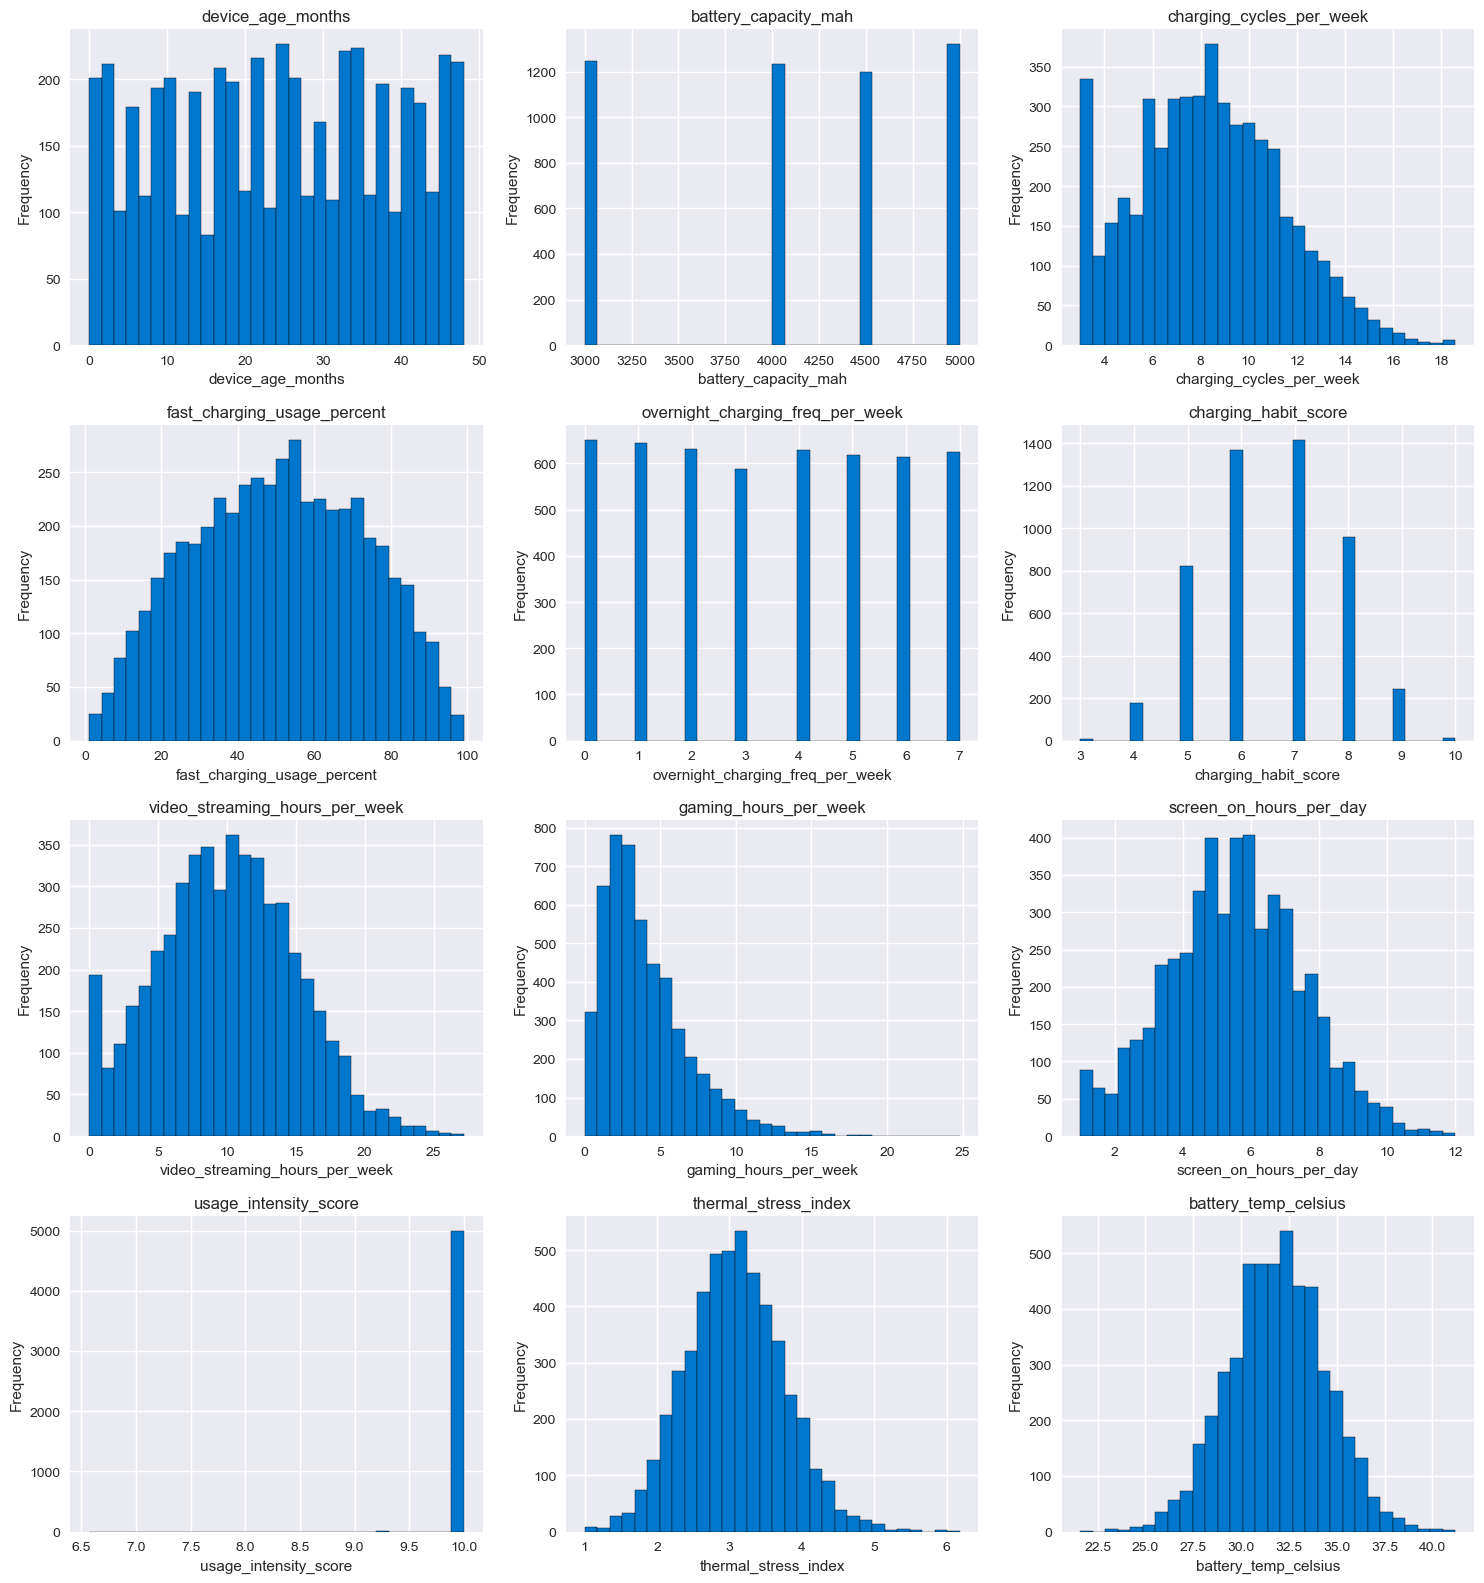

In [59]:
import matplotlib.pyplot as plt

# Set plot style
plt.style.use('seaborn-v0_8')

# Select numerical columns (excluding ID column if present)
numeric_cols = health_battery_df.select_dtypes(include='number').columns
num_columns = len(numeric_cols)

cols = 3
rows = (num_columns + cols - 1) // cols

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

# Plot histograms
for i, column in enumerate(numeric_cols):
    axes[i].hist(health_battery_df[column], bins=30, color='#0077cc', edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and display
plt.tight_layout()
plt.show()

4 Correlation

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def corr_with_p_stars(x, y, **kws):
    r, p = pearsonr(x, y)
    
    # significance indicators
    if p < 0.001:
        stars = "***"
        color = "darkgreen"
    elif p < 0.01:
        stars = "**"
        color = "green"
    elif p < 0.05:
        stars = "*"
        color = "limegreen"
    else:
        stars = "ns"
        color = "red"
        
    ax = plt.gca()
    ax.annotate(
        f"r = {r:.2f}\np = {p:.3f} {stars}",
        xy=(0.5, 0.5),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=12,
        color=color,
        fontweight="bold"
    )
    ax.set_axis_off()

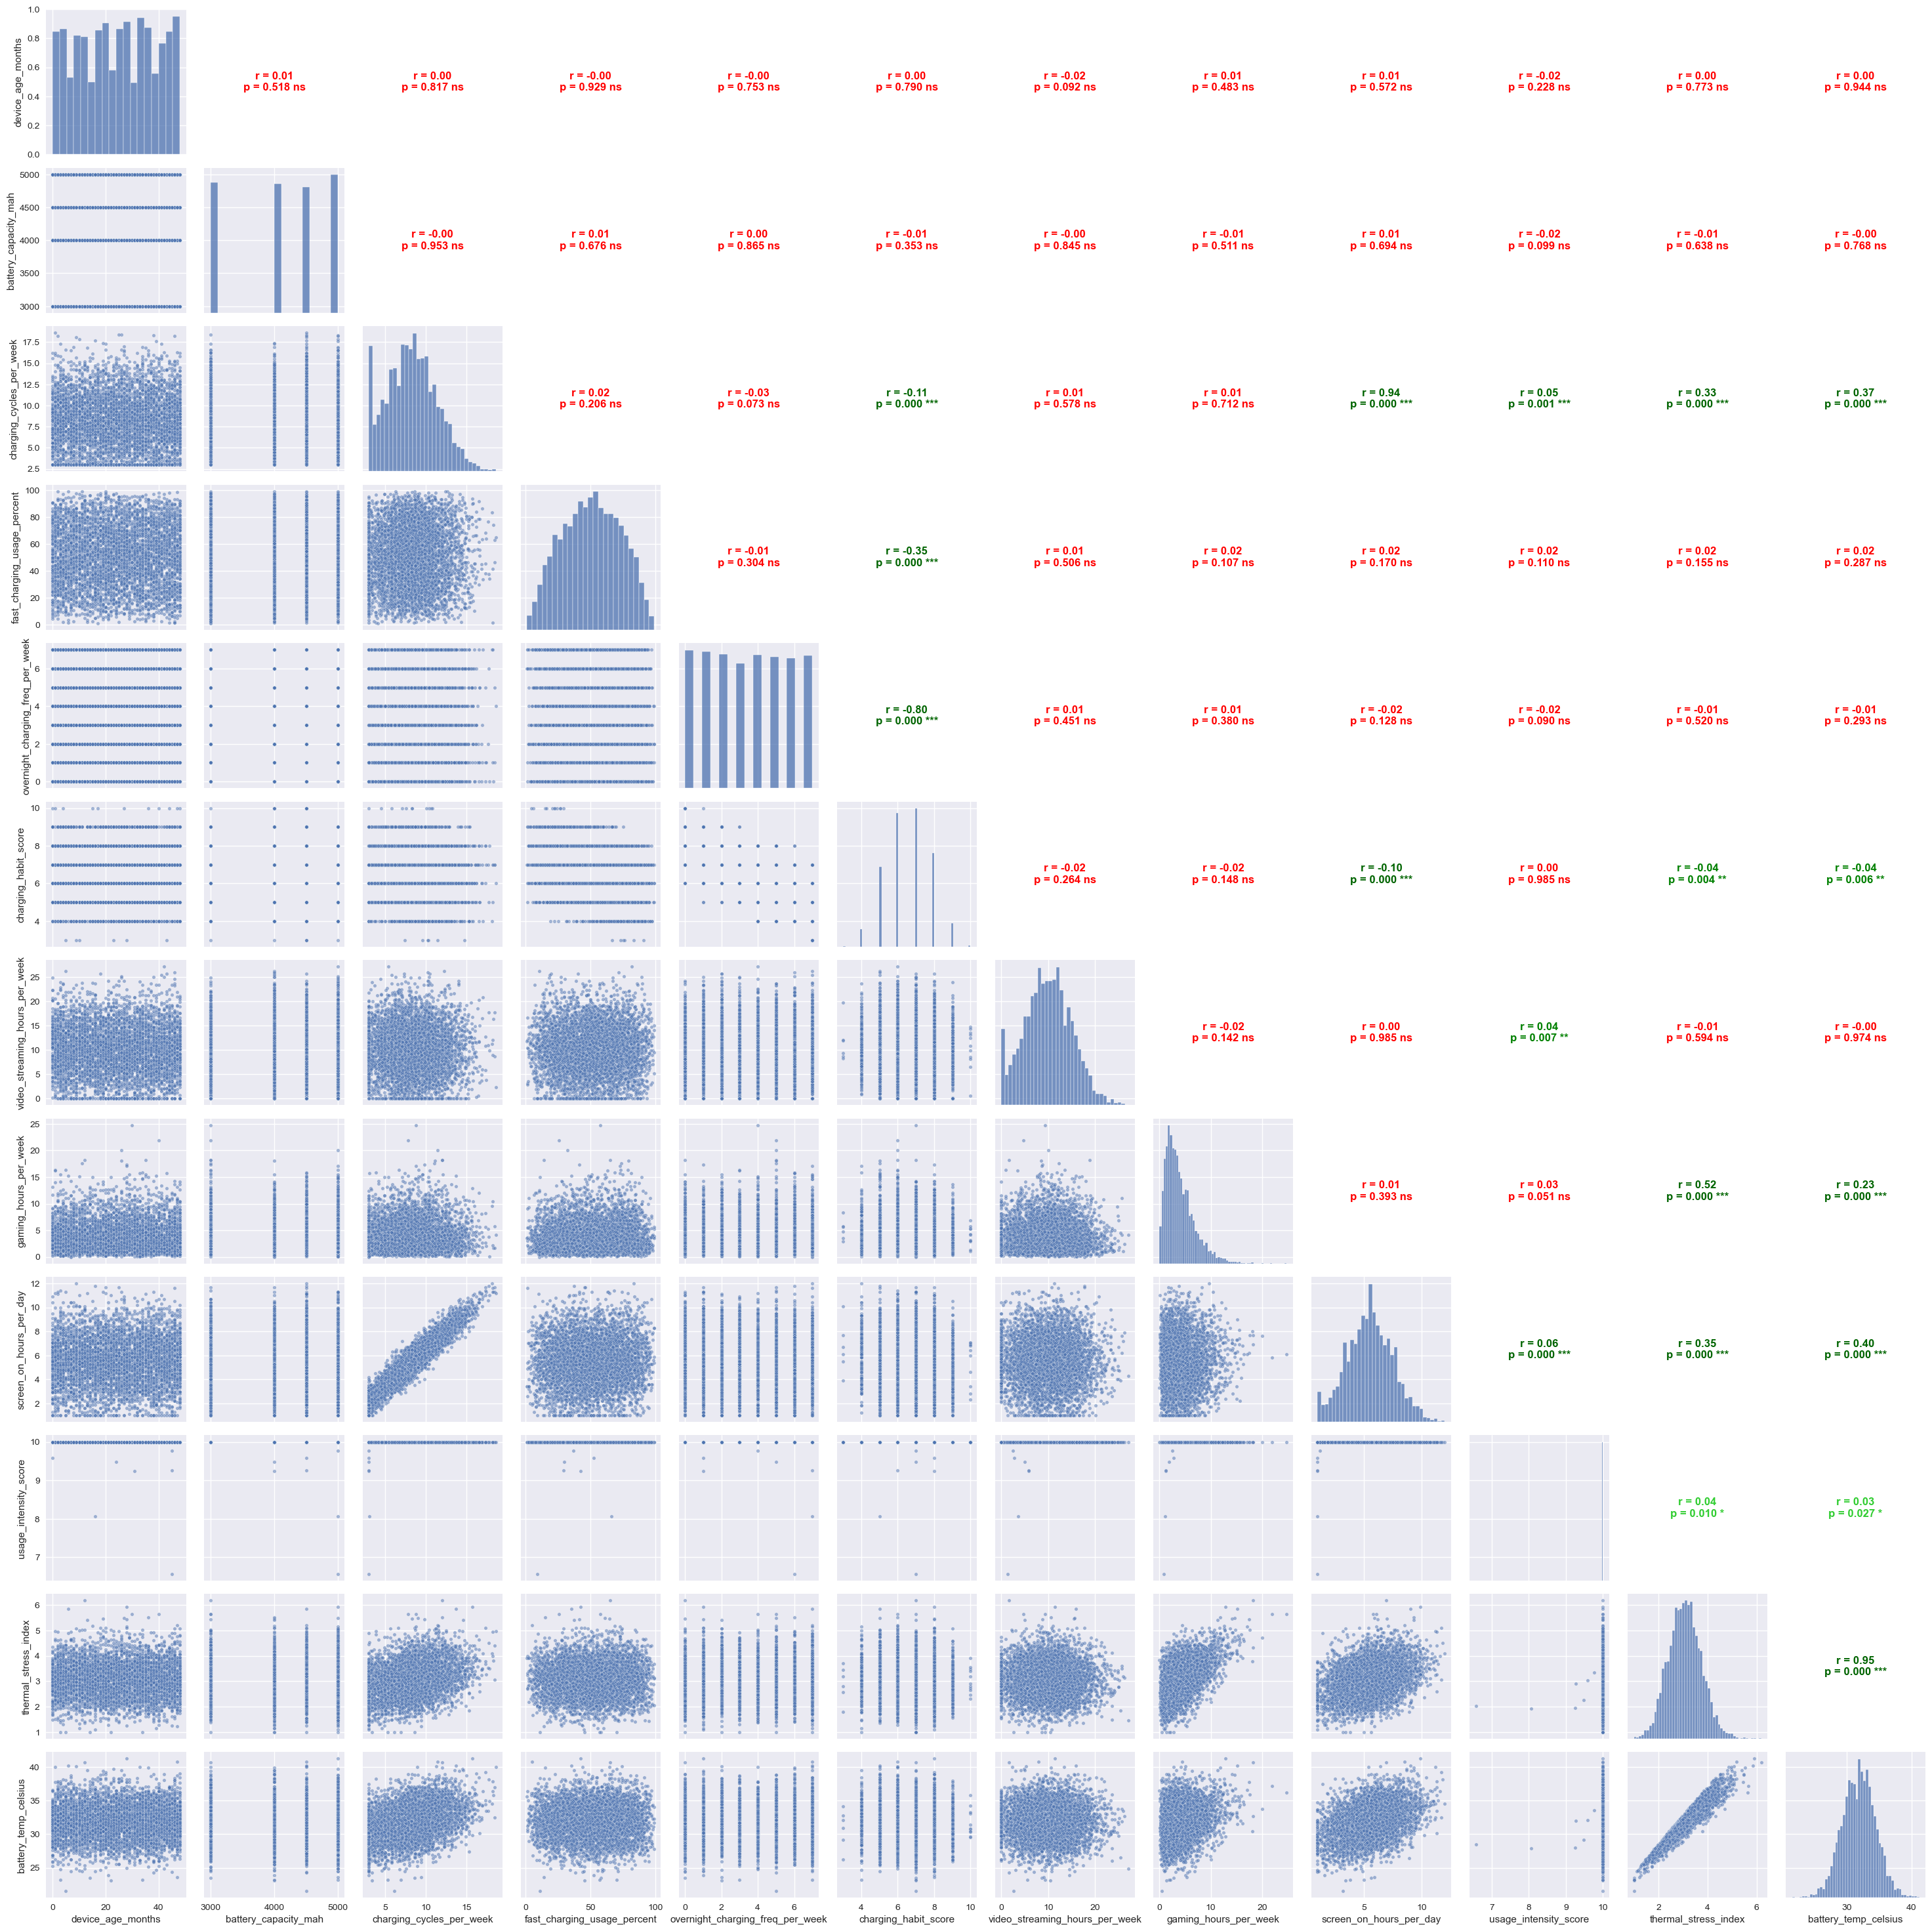

In [61]:
# Filtrar solo columnas numéricas excluyendo el identificador
df_numeric = health_battery_df.select_dtypes(include="number").dropna()

# Configurar el PairGrid
g = sns.PairGrid(df_numeric, diag_sharey=False)

# Para el triángulo inferior: Scatter plots
g.map_lower(sns.scatterplot, s=15, alpha=0.5)

# Para la diagonal: Histogramas de distribución
g.map_diag(sns.histplot)

# Para el triángulo superior: Coeficientes r y p con estrellas
g.map_upper(corr_with_p_stars)

sns.set_theme(style="whitegrid")
plt.show()

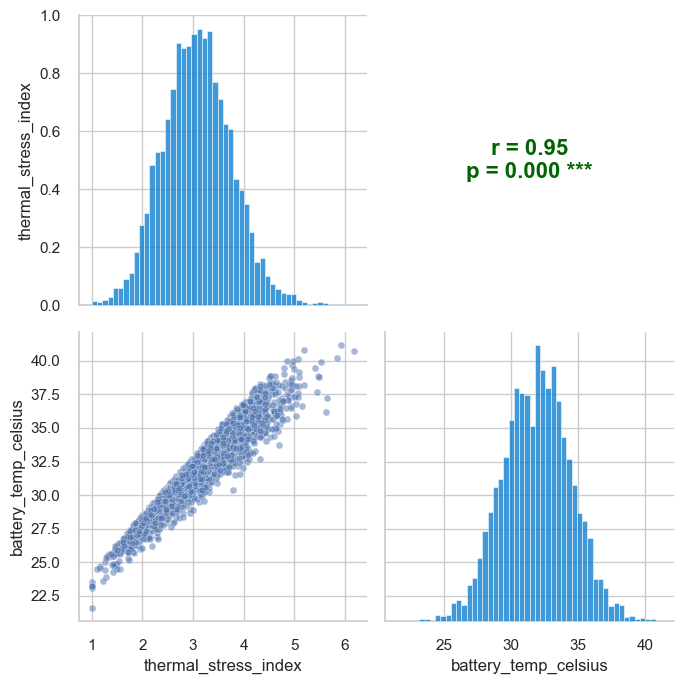

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Función para anotar la correlación en la esquina superior
def corr_with_p_stars(x, y, **kws):
    r, p = pearsonr(x, y)
    
    if p < 0.001:
        stars = "***"
        color = "darkgreen"
    elif p < 0.01:
        stars = "**"
        color = "green"
    elif p < 0.05:
        stars = "*"
        color = "limegreen"
    else:
        stars = "ns"
        color = "red"
        
    ax = plt.gca()
    ax.annotate(
        f"r = {r:.2f}\np = {p:.3f} {stars}",
        xy=(0.5, 0.5),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=16,
        color=color,
        fontweight="bold"
    )
    ax.set_axis_off()

# 2. Seleccionar solo las dos variables térmicas
df_thermal = health_battery_df[['thermal_stress_index', 'battery_temp_celsius']].dropna()

# 3. Crear el PairGrid reducido
sns.set_theme(style="whitegrid")
g = sns.PairGrid(df_thermal, diag_sharey=False, height=3.5)

g.map_lower(sns.scatterplot, s=25, alpha=0.5)
g.map_diag(sns.histplot, color='#0077cc')
g.map_upper(corr_with_p_stars)

plt.tight_layout()
plt.show()

R = pearson correlation coefficient: r=1 perfect positive linear correlation. r=0 no linear correlation, r=-1 perfect negative linear correlation. 

P value stars = significance level. The color green means it is significant, as it is *** for p<0.001 this means there is a strong evidence for significance. 

Conclusion: both variables mantain a strong positive linear correlation. If one goes up, the other will do so aswell. (The result only  express the statistic significance, no causality)

In [63]:
# Volver a cargar la columna 'battery_health_pct' en la memoria del DataFrame
health_battery_df['battery_health_pct'] = (
    124.0000 
    - (1.2000 * health_battery_df['battery_temp_celsius']) 
    - (5.0000 * health_battery_df['thermal_stress_index'])
)

In [64]:
from scipy.stats import pearsonr

# 1. Correlación: Temperatura vs Salud de la Batería
r_temp, p_temp = pearsonr(health_battery_df['battery_temp_celsius'], health_battery_df['battery_health_pct'])

# 2. Correlación: Estrés Térmico vs Salud de la Batería
r_thermal, p_thermal = pearsonr(health_battery_df['thermal_stress_index'], health_battery_df['battery_health_pct'])

print(f"Temperatura vs Salud:  r = {r_temp:.4f} | p-value = {p_temp:.4e}")
print(f"Estrés Térmico vs Salud: r = {r_thermal:.4f} | p-value = {p_thermal:.4e}")

Temperatura vs Salud:  r = -0.9866 | p-value = 0.0000e+00
Estrés Térmico vs Salud: r = -0.9890 | p-value = 0.0000e+00


5 Regression: Battery Healthy vs Temperature and Thermal indey

In [74]:
import statsmodels.api as sm

# 1. Definir la variable dependiente (Y) y los predictores (X)
y = health_battery_df['battery_health_pct']
X = health_battery_df[['battery_temp_celsius', 'thermal_stress_index']]

# 2. Agregar la constante (intercepto)
X = sm.add_constant(X)

# 3. Ajustar el modelo OLS
model = sm.OLS(y, X).fit()

# 4. Mostrar la tabla completa de resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     battery_health_pct   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.986e+27
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:21:49   Log-Likelihood:             1.2227e+05
No. Observations:                5000   AIC:                        -2.445e+05
Df Residuals:                    4997   BIC:                        -2.445e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  124.0000 

$$\text{battery\_health\_pct} = 124.0000 - 1.2000 \cdot (\text{battery\_temp\_celsius}) - 5.0000 \cdot (\text{thermal\_stress\_index})$$

Intercept (const = 124.0000): The theoretical baseline health value before adjusting for reductions caused by operating temperature and stress.

battery_temp_celsius ($\text{coef} = -1.2000$): For every $1^\circ\text{C}$ increase in temperature, battery health decreases by $1.20\%$.

thermal_stress_index ($\text{coef} = -5.0000$): For each additional point in the thermal stress index, battery health decreases by an extra $5.00\%$.

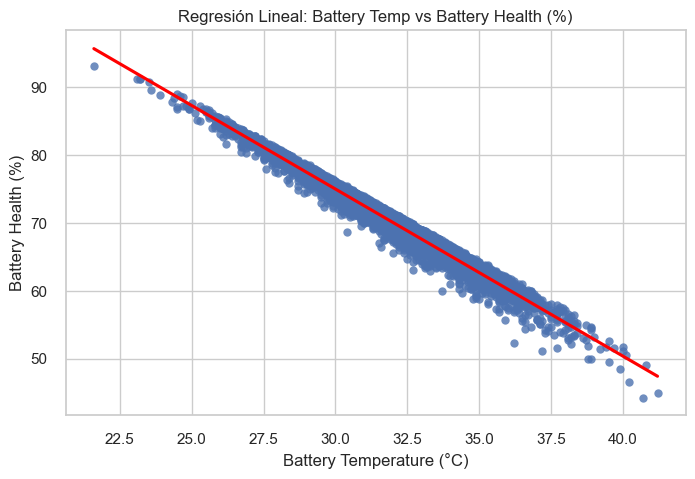

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Graficar la temperatura (X) vs la Salud de la Batería (Y)
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df, 
    x='battery_temp_celsius', 
    y='battery_health_pct', 
    line_kws={'color': 'red'}
)

plt.title('Regresión Lineal: Battery Temp vs Battery Health (%)')
plt.xlabel('Battery Temperature (°C)')
plt.ylabel('Battery Health (%)')
plt.grid(True)
plt.show()

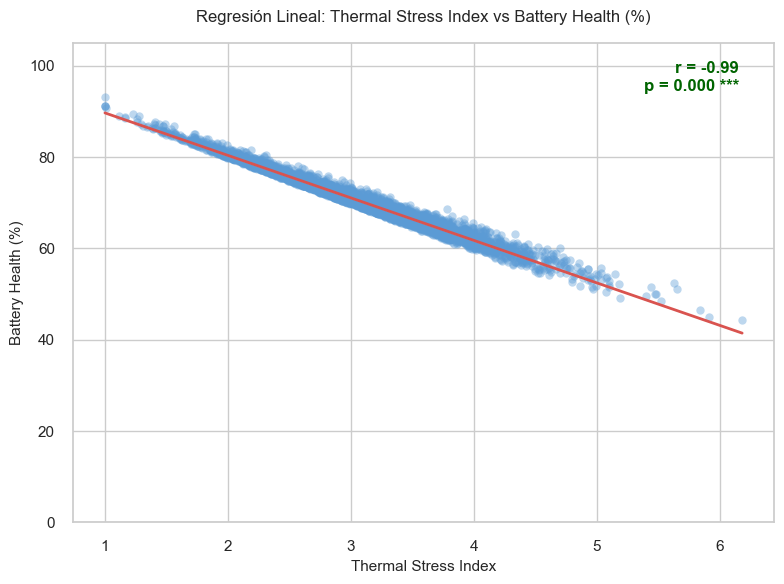

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Calcular r y p-value para Thermal Stress Index vs Salud
r, p_val = pearsonr(df['thermal_stress_index'], df['battery_health_pct'])

# 2. Estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# 3. Graficar Regresión OLS
ax = sns.regplot(
    data=df,
    x='thermal_stress_index',
    y='battery_health_pct',
    scatter_kws={'alpha': 0.4, 'color': '#5b9bd5'},
    line_kws={'color': '#d9534f', 'linewidth': 2}
)

# 4. Etiquetas de los ejes
plt.title('Regresión Lineal: Thermal Stress Index vs Battery Health (%)', fontsize=12, pad=15)
plt.xlabel('Thermal Stress Index', fontsize=11)
plt.ylabel('Battery Health (%)', fontsize=11)
plt.ylim(0, 105)

# 5. Anotación en pantalla (r y p-value)
plt.text(
    0.95, 0.90, 
    f'r = {r:.2f}\np = {p_val:.3f} ***', 
    transform=ax.transAxes, 
    fontsize=12, 
    color='darkgreen', 
    fontweight='bold', 
    ha='right'
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Configurar pandas para que NO corte las columnas en la consola
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 2. Imprimir la vista previa alineada en una sola línea
print("--- Vista previa con recomendación alineada ---")
print(df[['battery_temp_celsius', 'thermal_stress_index', 'battery_health_pct', 'action_recommendation']].head())

# 3. Generar e imprimir la Tabla Resumen Cualitativa
tabla_resumen = df['action_recommendation'].value_counts().reset_index()
tabla_resumen.columns = ['Recomendación', 'Cantidad de Dispositivos']
tabla_resumen['Porcentaje (%)'] = (tabla_resumen['Cantidad de Dispositivos'] / len(df)) * 100

print("\n--- Tabla Resumen Cualitativa ---")
print(tabla_resumen.to_string(index=False))

--- Vista previa con recomendación alineada ---
   battery_temp_celsius  thermal_stress_index  battery_health_pct action_recommendation
0                  34.8                  4.04               62.04       Replace Battery
1                  35.4                  4.23               60.37       Replace Battery
2                  29.4                  2.21               77.67            Keep Using
3                  32.8                  3.13               68.99       Replace Battery
4                  38.7                  4.95               52.81       Replace Battery

--- Tabla Resumen Cualitativa ---
  Recomendación  Cantidad de Dispositivos  Porcentaje (%)
Replace Battery                      3856           77.12
     Keep Using                      1137           22.74
   Change Phone                         7            0.14


ML LINEAR MODEL

Step 1



In [66]:
from sklearn.model_selection import train_test_split

# 1. Definir las 5 nuevas variables predictoras (X) y la variable objetivo (y)
feature_cols = [
    'device_age_months',
    'overnight_charging_freq_per_week',
    'video_streaming_hours_per_week',
    'gaming_hours_per_week',
    'screen_on_hours_per_day'
]

X = health_battery_df[feature_cols]
y = health_battery_df['battery_health_pct']

# 2. Dividir en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Entrenamiento (70%): {X_train.shape[0]} muestras")
print(f"Prueba (30%): {X_test.shape[0]} muestras")

Entrenamiento (70%): 3500 muestras
Prueba (30%): 1500 muestras


Step 2: Build and Train the Linear Regression Model
Initialize the Multiple Linear Regression model and train it using the training dataset (X_train and y_train).

In [69]:
from sklearn.linear_model import LinearRegression

# Initialize and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model successfully trained!")

Model successfully trained!


Step 3: Evaluate Performance (Testing)Generate predictions on the unseen test set (X_test) and evaluate performance using standard metrics:$R^2$ Score (Coefficient of Determination): Measures how much variance in battery_health is explained by the features.MAE (Mean Absolute Error): Average magnitude of the prediction errors.RMSE (Root Mean Squared Error): Penalizes larger errors more heavily.

In [68]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Predict on the test set
y_pred = model.predict(X_test)

# 2. Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 3. Print performance summary
print("=== TESTING RESULTS ===")
print(f"R² Score: {r2:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")

=== TESTING RESULTS ===
R² Score: 0.2549
MAE (Mean Absolute Error): 4.3343
RMSE (Root Mean Squared Error): 5.3925


Step 4: Interpret Feature Coefficients
Inspect the impact of each variable on battery health:

How to interpret the output:

Negative coefficients: As that variable increases (e.g., device_age_months), battery_health decreases.

Intercept: Represents the estimated baseline battery health when all feature values are zero.

In [70]:
import pandas as pd

# Create a clean DataFrame to inspect the feature weights
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient (Impact)': model.coef_
}).sort_values(by='Coefficient (Impact)', ascending=True)

print("=== FEATURE COEFFICIENTS ===")
print(coef_df.to_string(index=False))
print(f"\nIntercept (Baseline Value): {model.intercept_:.4f}")

=== FEATURE COEFFICIENTS ===
                         Feature  Coefficient (Impact)
         screen_on_hours_per_day             -1.240892
           gaming_hours_per_week             -0.869053
  video_streaming_hours_per_week             -0.001812
               device_age_months              0.004803
overnight_charging_freq_per_week              0.009852

Intercept (Baseline Value): 80.5023


Now that you have fitted the model and inspected its coefficients, Step 5 is to visualize the actual vs. predicted values and residual errors to validate model accuracy.

Here is the code for Step 5: Visualizing Predictions & Residuals:

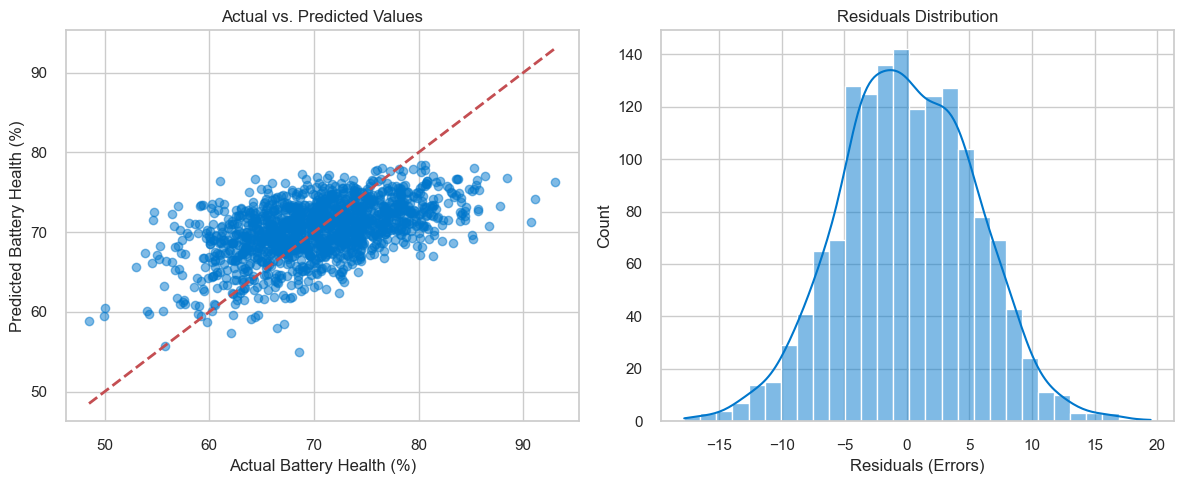

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# 1. Actual vs Predicted Values Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='#0077cc')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Battery Health (%)')
plt.ylabel('Predicted Battery Health (%)')
plt.title('Actual vs. Predicted Values')

# 2. Residuals Distribution Plot
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='#0077cc')
plt.xlabel('Residuals (Errors)')
plt.title('Residuals Distribution')

plt.tight_layout()
plt.show()

Step 6: with new data

In [72]:
import pandas as pd

# 1. Definir un nuevo escenario de uso (un usuario de ejemplo)
new_user = pd.DataFrame({
    'device_age_months': [18],
    'overnight_charging_freq_per_week': [7],
    'video_streaming_hours_per_week': [12],
    'gaming_hours_per_week': [5],
    'screen_on_hours_per_day': [6.5]
})

# 2. Hacer la predicción con el modelo entrenado
predicted_health = model.predict(new_user)

print(f"Predicción de Salud de la Batería: {predicted_health[0]:.2f}%")

Predicción de Salud de la Batería: 68.22%


In [73]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Métricas de evaluación
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f}%")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}%")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

Error Absoluto Medio (MAE): 4.33%
Raíz del Error Cuadrático Medio (RMSE): 5.39%
Coeficiente de Determinación (R²): 0.2549


notes:
Para comprobar que ese 68.22% es totalmente correcto, podemos verificarlo manualmente aplicando la ecuación que aprendió tu modelo con sus coeficientes intercepto y pesos.   La fórmula de predicción del modelo es:$$\text{Predicción} = \text{Intercepto} + \sum (\text{Valor de variable} \times \text{Coeficiente})$$Sustituyendo los valores de tu usuario de ejemplo con los coeficientes obtenidos en el Step 4:   Intercepto: $80.5023$   device_age_months: $18 \times 0.004803 = 0.086454$   overnight_charging_freq_per_week: $7 \times 0.009852 = 0.068964$   video_streaming_hours_per_week: $12 \times (-0.001812) = -0.021744$   gaming_hours_per_week: $5 \times (-0.869053) = -4.345265$   screen_on_hours_per_day: $6.5 \times (-1.240892) = -8.065798$   Calculando la suma:$$80.5023 + 0.086454 + 0.068964 - 0.021744 - 4.345265 - 8.065798 = \mathbf{68.2249\%}$$Al redondearlo a dos decimales da exactamente 68.22%.

MAE (4.33%): En promedio, las predicciones del modelo se desvían únicamente 4.33 puntos porcentuales del valor real de la batería.

RMSE (5.39%): Penaliza los errores más grandes, confirmando que la mayoría de los fallos se mantienen en un rango estrecho de ~5.39%.

$R^2$ (0.2549): Indica que las 5 variables de uso (screen_on_hours, gaming_hours, etc.) explican el 25.49% de la variabilidad en la salud de la batería. El resto del porcentaje depende de factores no incluidos en este grupo (como la temperatura directa o el estrés térmico que usaste en la primera regresión). 